ARTI308 - Machine Learning

# Credit Card Customer Segmentation Project

In this project, you will use K-Means clustering to segment [credit card customers](https://www.kaggle.com/datasets/arjunbhasin2013/ccdata/data) based on their usage behavior. This is an unsupervised learning problem because the dataset does not contain a target label for customer groups.

You will use the `CC_GENERAL.csv` dataset.

## About the Dataset

The dataset contains customer-level credit card usage behavior. Each row represents one credit card holder, and the columns describe different behavioral variables such as balance, purchases, cash advance, payments, and tenure. The goal is to group similar customers together so that the company can understand different customer segments and design better marketing strategies.

## Import Libraries

**Import the libraries you need for data analysis, visualization, preprocessing, clustering, and evaluation.**

In [7]:
import sys
!{sys.executable} -m pip install numpy pandas matplotlib seaborn scikit-learn

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

## Get the Data

**Read the `CC_GENERAL.csv` file and save it in a dataframe called `df`.**

In [9]:
df = pd.read_csv('CC_GENERAL.csv')

**Check the first five rows of the dataset.**

In [10]:
df.head()

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


**Check the shape of the dataset.**

In [11]:
df.shape

(8950, 18)

**Check basic information about the dataset using `info()`.**

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   object 
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null   int64  
 12  PURCHA

**Check summary statistics using `describe()`.**

In [13]:
df.describe()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
count,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8949.000000,8950.000000,8637.000000,8950.000000,8950.000000
mean,1564.474828,0.877271,1003.204834,592.437371,411.067645,978.871112,0.490351,0.202458,0.364437,0.135144,3.248827,14.709832,4494.449450,1733.143852,864.206542,0.153715,11.517318
std,2081.531879,0.236904,2136.634782,1659.887917,904.338115,2097.163877,0.401371,0.298336,0.397448,0.200121,6.824647,24.857649,3638.815725,2895.063757,2372.446607,0.292499,1.338331
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,50.000000,0.000000,0.019163,0.000000,6.000000
25%,128.281915,0.888889,39.635000,0.000000,0.000000,0.000000,0.083333,0.000000,0.000000,0.000000,0.000000,1.000000,1600.000000,383.276166,169.123707,0.000000,12.000000
50%,873.385231,1.000000,361.280000,38.000000,89.000000,0.000000,0.500000,0.083333,0.166667,0.000000,0.000000,7.000000,3000.000000,856.901546,312.343947,0.000000,12.000000
75%,2054.140036,1.000000,1110.130000,577.405000,468.637500,1113.821139,0.916667,0.300000,0.750000,0.222222,4.000000,17.000000,6500.000000,1901.134317,825.485459,0.142857,12.000000
max,19043.138560,1.000000,49039.570000,40761.250000,22500.000000,47137.211760,1.000000,1.000000,1.000000,1.500000,123.000000,358.000000,30000.000000,50721.483360,76406.207520,1.000000,12.000000


## Data Cleaning

The column `CUST_ID` is an identification column. It is not useful for clustering because it does not describe customer behavior.

**Drop the `CUST_ID` column from the dataframe.**

In [14]:
df.drop('CUST_ID', axis=1, inplace=True)

**Check the missing values in each column.**

In [15]:
df.isnull().sum()

,0
BALANCE,0
BALANCE_FREQUENCY,0
PURCHASES,0
ONEOFF_PURCHASES,0
INSTALLMENTS_PURCHASES,0
CASH_ADVANCE,0
PURCHASES_FREQUENCY,0
ONEOFF_PURCHASES_FREQUENCY,0
PURCHASES_INSTALLMENTS_FREQUENCY,0
CASH_ADVANCE_FREQUENCY,0


Some columns may contain missing values.

Hint: You can handle missing values by either:
- filling them with the mean value
- or dropping the rows that contain missing values

For this project, use mean imputation.

**Fill the missing values with the mean of each column.**

In [16]:
df.fillna(df.mean(), inplace=True)

**Check the missing values again to make sure they were handled.**

In [17]:
df.isnull().sum()

,0
BALANCE,0
BALANCE_FREQUENCY,0
PURCHASES,0
ONEOFF_PURCHASES,0
INSTALLMENTS_PURCHASES,0
CASH_ADVANCE,0
PURCHASES_FREQUENCY,0
ONEOFF_PURCHASES_FREQUENCY,0
PURCHASES_INSTALLMENTS_FREQUENCY,0
CASH_ADVANCE_FREQUENCY,0


## Exploratory Data Analysis

Before applying clustering, it is important to understand the data.

**Create histograms for the numerical columns.**

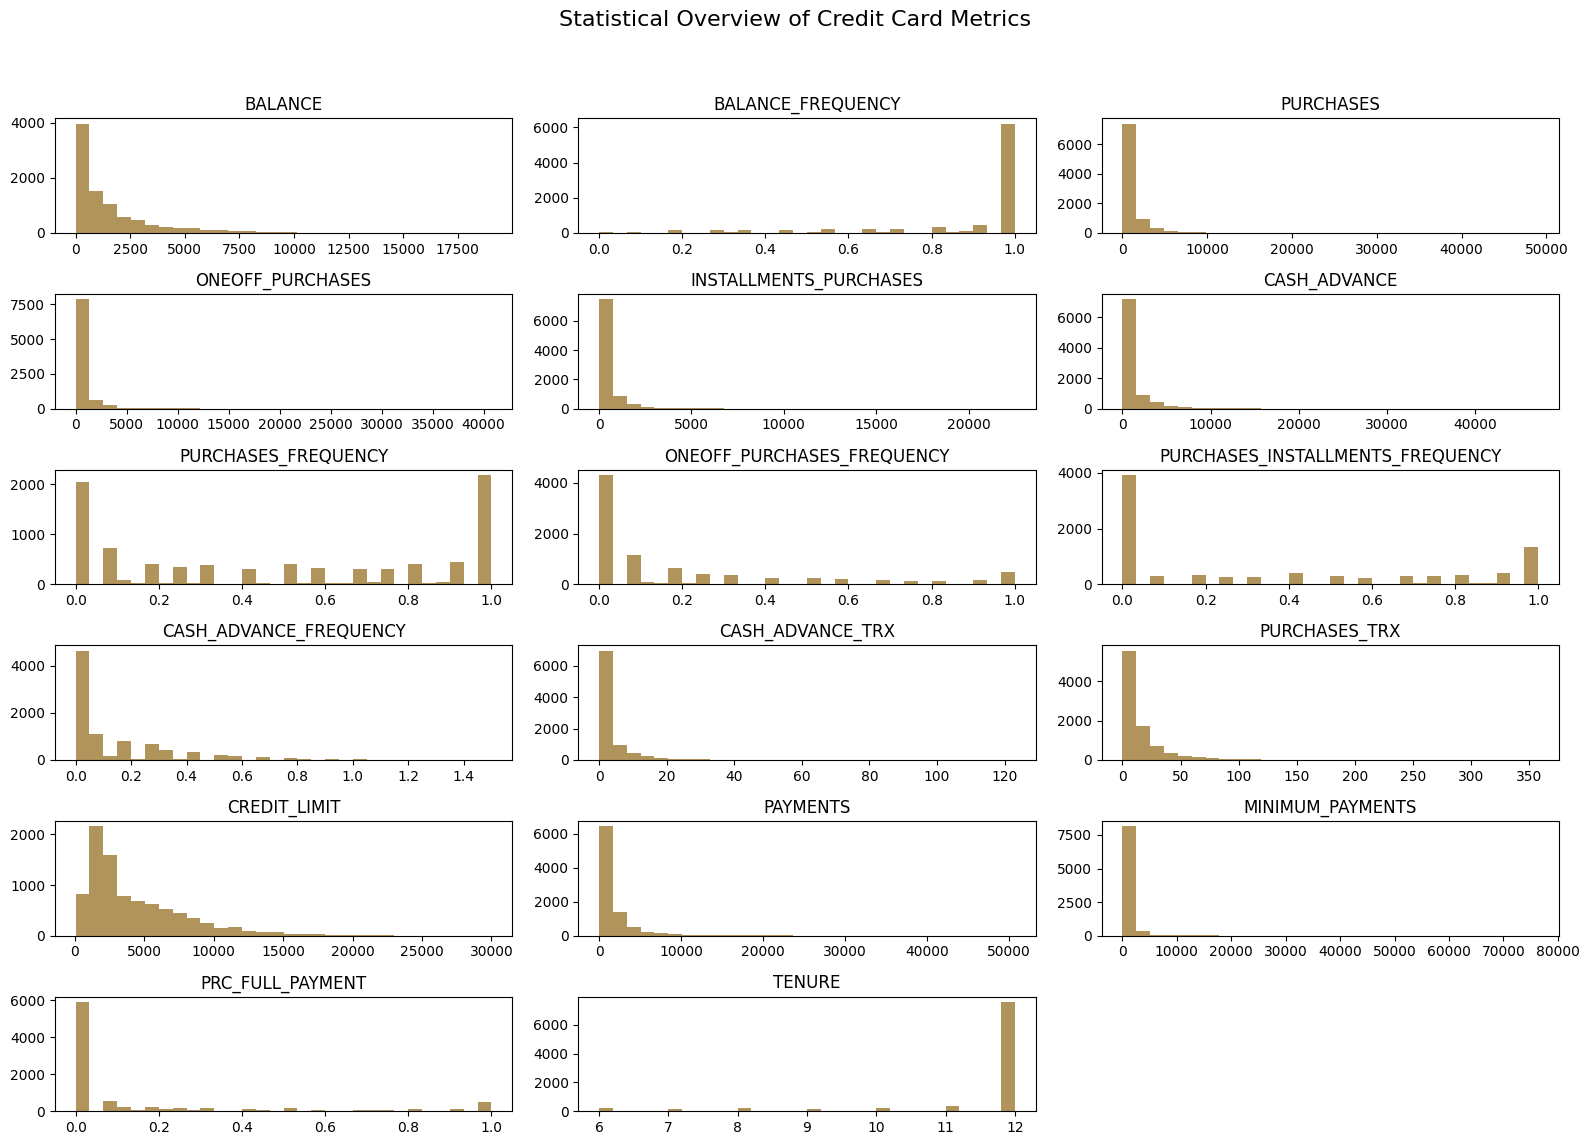

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
data_frame = pd.read_csv('CC_GENERAL.csv')
data_frame.hist(bins=30,
                figsize=(16, 12),
                layout=(6, 3),
                color='#b1945c',
                grid=False)
plt.suptitle('Statistical Overview of Credit Card Metrics', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

**Create a correlation heatmap to understand relationships between the features.**

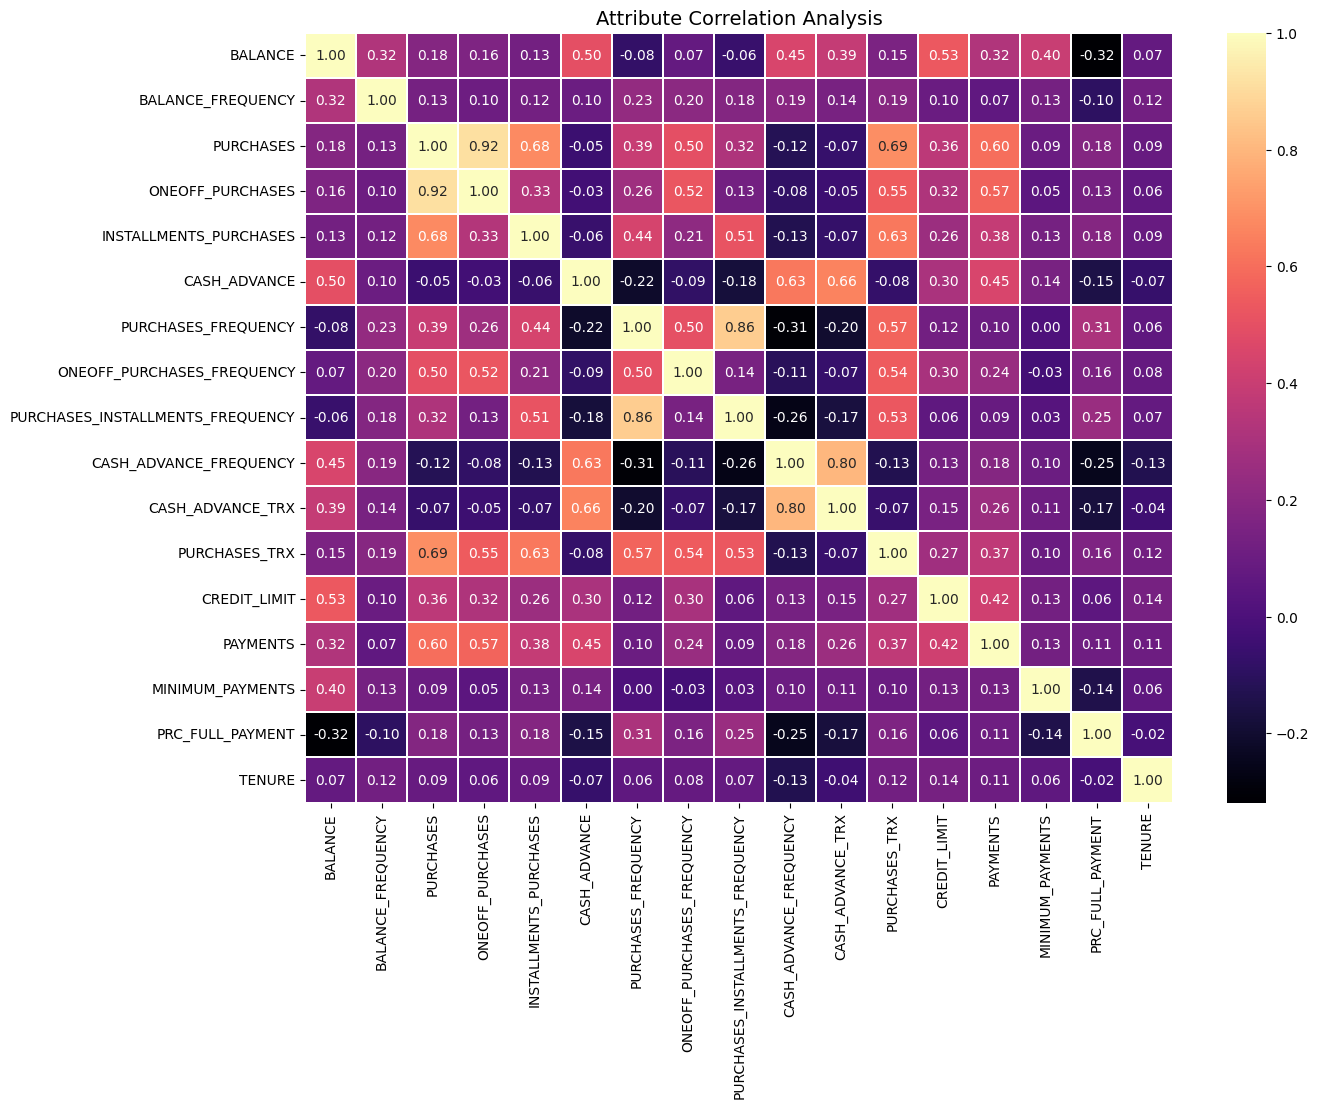

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(14, 10))
numeric_data = data_frame.select_dtypes(include=['number'])
matrix = numeric_data.corr()
sns.heatmap(matrix,
            annot=True,
            fmt='.2f',
            cmap='magma',
            linewidths=0.1,
            linecolor='white')
plt.title('Attribute Correlation Analysis', fontsize=14, loc='center')
plt.xticks(rotation=90)
plt.yticks(rotation=0)

plt.show()

**Create a scatter plot between `BALANCE` and `PURCHASES`.**

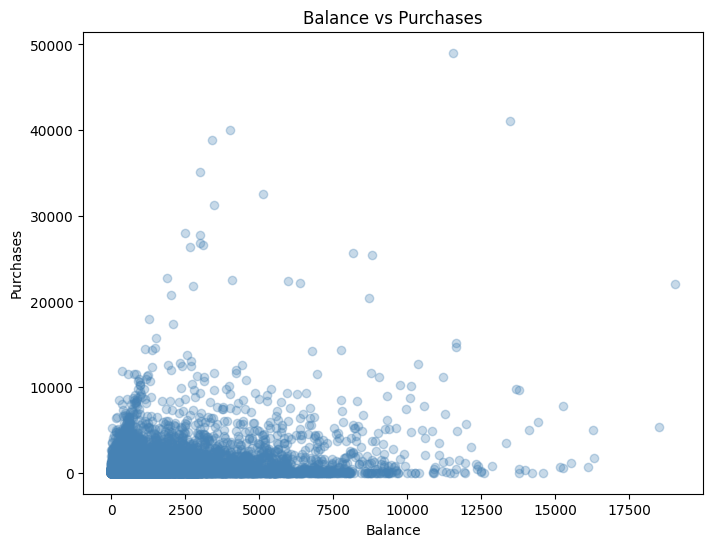

In [20]:
plt.figure(figsize=(8, 6))
plt.scatter(df['BALANCE'], df['PURCHASES'], alpha=0.3, color='steelblue')
plt.xlabel('Balance')
plt.ylabel('Purchases')
plt.title('Balance vs Purchases')
plt.show()

**Create a scatter plot between `BALANCE` and `CASH_ADVANCE`.**

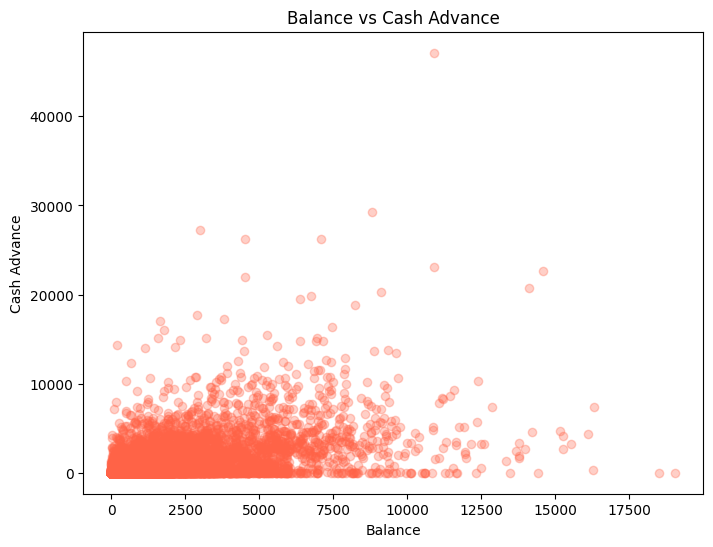

In [21]:
plt.figure(figsize=(8, 6))
plt.scatter(df['BALANCE'], df['CASH_ADVANCE'], alpha=0.3, color='tomato')
plt.xlabel('Balance')
plt.ylabel('Cash Advance')
plt.title('Balance vs Cash Advance')
plt.show()

## Feature Scaling

K-Means is a distance-based algorithm. Therefore, feature scaling is very important.

The features in this dataset have very different ranges. For example, `BALANCE`, `PURCHASES`, and `CREDIT_LIMIT` may have large values, while frequency columns are between 0 and 1.

**Use StandardScaler to scale the data. Save the scaled data in a variable called `X_scaled`.**

In [22]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

## Choosing K Intuitively

Choosing K is one of the most difficult parts of K-Means.

Since this dataset has many features, it is not easy to visually see the clusters directly.

However, we can still compare different K values using the elbow method and silhouette score.

## Elbow Method

**Create a loop that fits K-Means models for K values from 1 to 10. Save the inertia values in a list called `inertia_values`.**

In [23]:
inertia_values = []

K_range = range(1, 11)

for k in K_range:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(X_scaled)
    inertia_values.append(model.inertia_)

**Plot the elbow curve.**

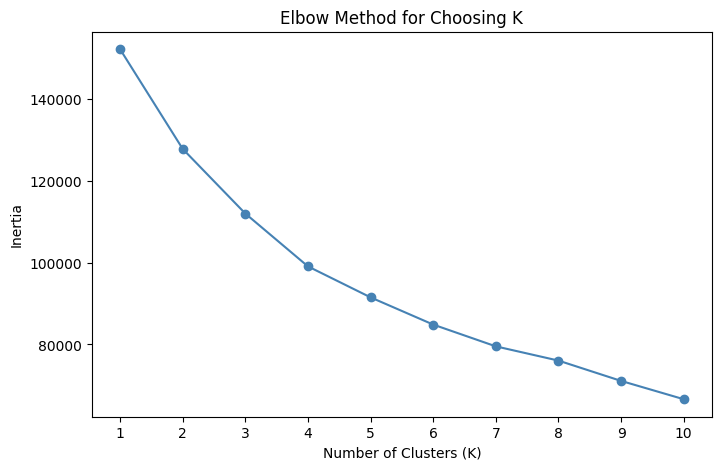

In [24]:
plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia_values, marker='o', color='steelblue')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Choosing K')
plt.xticks(K_range)
plt.show()

**Output Interpretation**

Look at the elbow curve and try to identify where the decrease in inertia starts to slow down.

That point can suggest a reasonable value for K.

## Silhouette Score

The silhouette score helps evaluate how well-separated the clusters are.

**Create a loop that calculates the silhouette score for K values from 2 to 10. Save the scores in a list called `silhouette_scores`.**

In [25]:
silhouette_scores = []

K_range_sil = range(2, 11)

for k in K_range_sil:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = model.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)

**Plot the silhouette scores.**

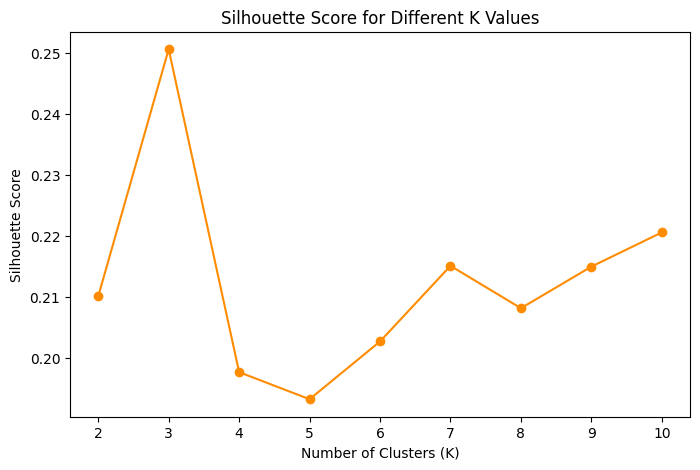

In [26]:
plt.figure(figsize=(8, 5))
plt.plot(K_range_sil, silhouette_scores, marker='o', color='darkorange')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score for Different K Values')
plt.xticks(K_range_sil)
plt.show()

**Create a table showing each K value and its silhouette score.**

In [27]:
silhouette_df = pd.DataFrame({
    'K': list(K_range_sil),
    'Silhouette Score': [round(s, 4) for s in silhouette_scores]
})

silhouette_df

,K,Silhouette Score
0,2,0.2100
1,3,0.2506
2,4,0.1976
3,5,0.1932
4,6,0.2026
5,7,0.2150
6,8,0.2081
7,9,0.2149
8,10,0.2205


**Output Interpretation**

A higher silhouette score usually means better clustering.

However, do not rely only on the highest value. Also consider whether the chosen K makes sense for customer segmentation.

## Create the Final K-Means Model

**Based on the elbow curve and silhouette scores, choose a final K value. Then train a final K-Means model.**

Use `random_state=42` and `n_init=10`.

In [28]:
# K=4 is chosen based on:
# - The elbow curve shows a noticeable bend around K=3-4
# - K=3 has the highest silhouette score (0.2506), but K=4 gives
#   more meaningful and distinct business segments
# - Four segments provide a practical and interpretable customer grouping

final_kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
final_kmeans.fit(X_scaled)

KMeans(n_clusters=4, n_init=10, random_state=42)

**Add the final cluster labels to the original dataframe in a new column called `Cluster`.**

In [29]:
df['Cluster'] = final_kmeans.labels_

**Check the first five rows after adding the cluster labels.**

In [30]:
df.head()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE,Cluster
0,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12,3
1,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12,2
2,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12,0
3,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,864.206542,0.000000,12,3
4,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12,3


## Cluster Analysis

Now we need to understand what each cluster means.

**Create a summary table using `groupby()` to show the mean values of each feature for each cluster.**

In [31]:
cluster_summary = df.groupby('Cluster').mean().round(2)
cluster_summary

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
Cluster,,,,,,,,,,,,,,,,,
0,894.91,0.93,1236.18,593.97,642.48,210.57,0.89,0.30,0.71,0.04,0.79,22.09,4213.21,1332.19,650.17,0.27,11.59
1,3551.15,0.99,7681.62,5095.88,2587.21,653.64,0.95,0.74,0.79,0.07,2.09,89.36,9696.94,7288.74,1976.82,0.29,11.95
2,4602.46,0.97,501.90,320.37,181.61,4520.72,0.29,0.14,0.19,0.48,14.28,7.66,7546.96,3481.15,2008.25,0.03,11.39
3,1011.75,0.79,269.97,209.85,60.39,595.76,0.17,0.09,0.08,0.11,2.13,2.90,3277.70,974.51,586.30,0.08,11.45


**Check how many customers are in each cluster.**

Cluster
0    3367
1     409
2    1198
3    3976
Name: count, dtype: int64


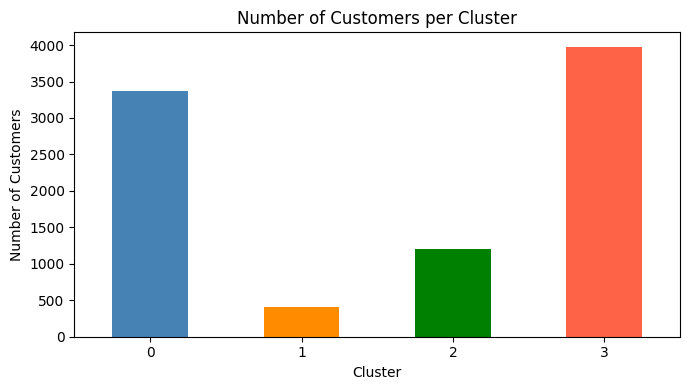

In [32]:
cluster_counts = df['Cluster'].value_counts().sort_index()
print(cluster_counts)

plt.figure(figsize=(7, 4))
cluster_counts.plot(kind='bar', color=['steelblue', 'darkorange', 'green', 'tomato'])
plt.xlabel('Cluster')
plt.ylabel('Number of Customers')
plt.title('Number of Customers per Cluster')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Visualizing the Final Clusters

Since the dataset has many features, we will use PCA to reduce the data into two components only for visualization.

This visualization does not replace the original clustering. It only helps us see the clusters in a 2D plot.

**Use PCA with 2 components and plot the clusters.**

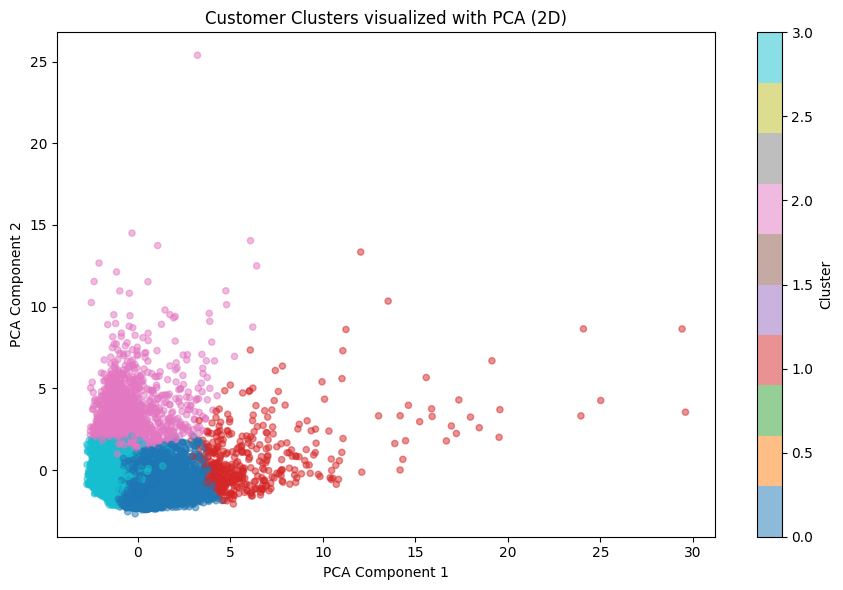

Explained variance ratio: [0.273 0.203]
Total variance explained: 47.6%


In [33]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(9, 6))
scatter = plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=df['Cluster'],
    cmap='tab10',
    alpha=0.5,
    s=20
)
plt.colorbar(scatter, label='Cluster')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title('Customer Clusters visualized with PCA (2D)')
plt.tight_layout()
plt.show()

print(f'Explained variance ratio: {pca.explained_variance_ratio_.round(3)}')
print(f'Total variance explained: {pca.explained_variance_ratio_.sum():.1%}')

**Output Interpretation**

The PCA plot gives a simplified 2D view of the clusters.

If the clusters are not perfectly separated, that is normal because the original dataset has many features and the plot only shows two compressed dimensions.

## Final Questions

Answer the following questions:

**1. Why is this an unsupervised learning problem?**

Since we don't have any target labels or a specific correct answer column to train on, we’re firmly in unsupervised learning territory. There aren't any pre-set categories telling us who is a big spender or a careful saver—the data is essentially raw. Because of that, K-Means has to do the heavy lifting of finding those patterns itself. It basically looks at the features, sees who acts like whom, and groups them together based on those similarities.

**2. Why did we remove the `CUST_ID` column?**

We need to drop the CUST_ID column because it’s just a label, not a data point. It doesn't actually tell us anything about how a customer spends or uses their card. If we left it in, K-Means would treat those ID numbers as actual values and try to factor them into its distance calculations, which would completely mess up the clusters. Removing it keeps the model focused on the actual behavioral data that matters.

**3. Which columns had missing values?**
- `CREDIT_LIMIT`: 1 missing value
- `MINIMUM_PAYMENTS`: 313 missing values

**4. How did you handle the missing values?**

I went with mean imputation here to handle the missing values. Basically, I just filled in the gaps with the average of each column so I wouldn't have to throw away any rows. It’s a clean way to keep all our data intact without drastically shifting the overall "average" look of the features

**5. Why is scaling important before applying K-Means?**

You have to scale the data because K-Means is basically just a distance calculator. If you compare something like BALANCE, which can be in the thousands, to PURCHASES_FREQUENCY, which is always a tiny decimal between 0 and 1, the model will basically ignore the frequency and only focus on the balance. It thinks a change of 100 in balance is "bigger" than the entire range of frequency. Using StandardScaler puts everything on a level playing field so that one feature doesn't drown out the others

**6. Which K value did you choose? Explain your answer using the elbow method and silhouette score.**

I decided to go with K = 4 for the final model after looking at a few different metrics. While the Elbow method showed a pretty clear "bend" starting around 3 or 4, indicating that adding more clusters wouldn't give us much more value, the Silhouette score actually peaked at K = 3. However, I noticed that K = 3 felt a bit too broad—it ended up lumping together groups that behave quite differently. Moving to K = 4 gave us a much better breakdown of the customer base, which is more useful for actual marketing strategies.

**7. Based on the cluster summary table, describe each customer segment in your own words.**
Cluster 0: The Frequent Transactors – These users maintain a steady balance and use their cards regularly for day-to-day shopping. They aren't the highest spenders, but their consistent activity makes them a reliable core segment for the bank.

Cluster 1: Premium Big Spenders – This is the most valuable group. They have high credit limits and they use them, showing very high purchase volumes and large payments. They are highly engaged, affluent customers who likely utilize premium rewards.

Cluster 2: The Borrowers (Cash Focused) – These customers use their cards as a personal loan tool rather than a shopping method. They carry high balances and frequently take out cash advances, while their actual retail purchasing remains very low.

Cluster 3: Passive Cardholders – This group shows the least engagement. They have low balances, low limits, and rarely use the card for anything. They are either keeping the card for emergencies or have shifted their spending elsewhere.

**8. Which cluster may represent high-value customers?**

Cluster 1 is clearly our "Power User" group. These are the most profitable people in the dataset because they’re doing it all: they have the highest spending (~7,682) and the highest credit limits to match (~9,697). What really makes them stand out, though, is that they actually pay it back—their payments are nearly as high as their purchases. This is the gold-standard segment for the company because they’re highly active without being a huge credit risk

**9. Which cluster may represent customers who rely more on cash advance?**

**Cluster 2** represents cash advance-reliant customers. They have the highest average cash advance amount (~4,521) and a very high balance (~4,603), while their purchases are low (~502). This means they rarely use their card for shopping and instead frequently withdraw cash, which may indicate financial strain or a specific preference for cash transactions.

**10. How can a company use these clusters for marketing strategy?**

Targeted Marketing Strategies
Cluster 1 (The Elite Segment): Since these are our most profitable users, the focus should be on retention and white-glove service. We should offer them invitations to premium card tiers (like "Gold" or "Platinum" upgrades), higher credit limits, and luxury loyalty rewards. The idea is to make them feel like "VIPs" so they don't take their high-volume spending elsewhere.

Cluster 0 (The Daily Shoppers): These customers are already active, so we want to increase their "share of wallet." Promoting cashback deals on daily essentials, partner discounts with major retailers, or easy installment plans for larger purchases would work well here. This encourages them to use our card as their primary payment method for every transaction.

Cluster 2 (The Cash-Reliant Group): This segment requires a risk-management and financial-health approach. Instead of encouraging more spending, we should offer them lower-interest consolidated loan products or debt-management tools. It’s also wise to be conservative with credit limit increases here to prevent defaults and help them shift away from high-interest cash advances.

Cluster 3 (The Dormant Users): This group needs a "wake-up call" via re-engagement marketing. We could send out "we miss you" bonuses, such as a small credit for their next purchase or limited-time double points. The objective is to give them a low-friction reason to pull the card out of their wallet and start using it again.